In [34]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel

# Save account to disk and save it as the default.
# QiskitRuntimeService.save_account(channel="ibm_quantum", token="ecf8a9fc1a30d0235c1ce7a4b088f6261de53f1167a467d96431088ee8dd280d00fe69b4f7e6fac14aec009733611c6dde440391fbf5ae1716d6baf540f413e4", name="Aniket")

# Load the saved credentials
service = QiskitRuntimeService(name="Aniket")
backend = service.backend("ibm_brisbane")
noise_hardware = NoiseModel.from_backend(backend)

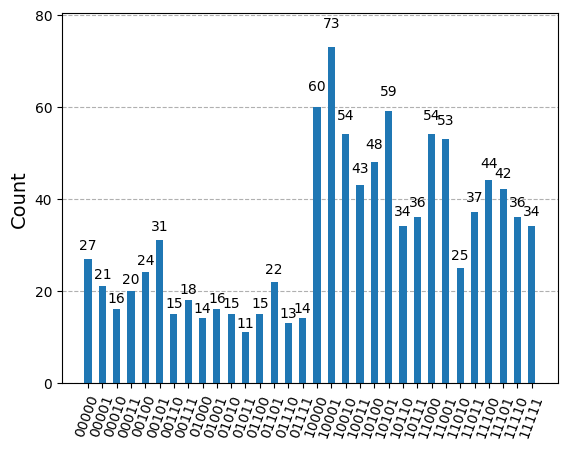

In [35]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel
from qiskit_aer import AerSimulator
from qiskit.circuit.random import random_circuit
from qiskit import transpile
from qiskit.visualization import plot_histogram

# Load IBM Quantum service and get the backend
service = QiskitRuntimeService(name="Aniket")
backend = service.backend("ibm_brisbane")

# Get the noise model from the backend
noise_model = NoiseModel.from_backend(backend)

# Generate a random circuit
num_qubits = 5
depth = 10
random_circ = random_circuit(num_qubits, depth, max_operands=2, measure=True)

# Transpile just for basis gates, no hardware mapping
transpiled_circ = transpile(random_circ, basis_gates=backend.configuration().basis_gates)# backend=backend) #basis_gates=backend.configuration().basis_gates


# Create a simulator with the noise model
simulator = AerSimulator(noise_model=noise_model)

# Run the transpiled circuit on the simulator
job = simulator.run(transpiled_circ, shots=1024)
result = job.result()
counts = result.get_counts()

# Plot the result histogram
plot_histogram(counts)

I know total types of gate, and error in the gate per qubit, in case of 2 qubit gate like ECR, i know readout error.

So for one quantum line, i can have edge_weight as 1(flawless) and for ECR i can have something like f(error)

barrier i dont need to consider?

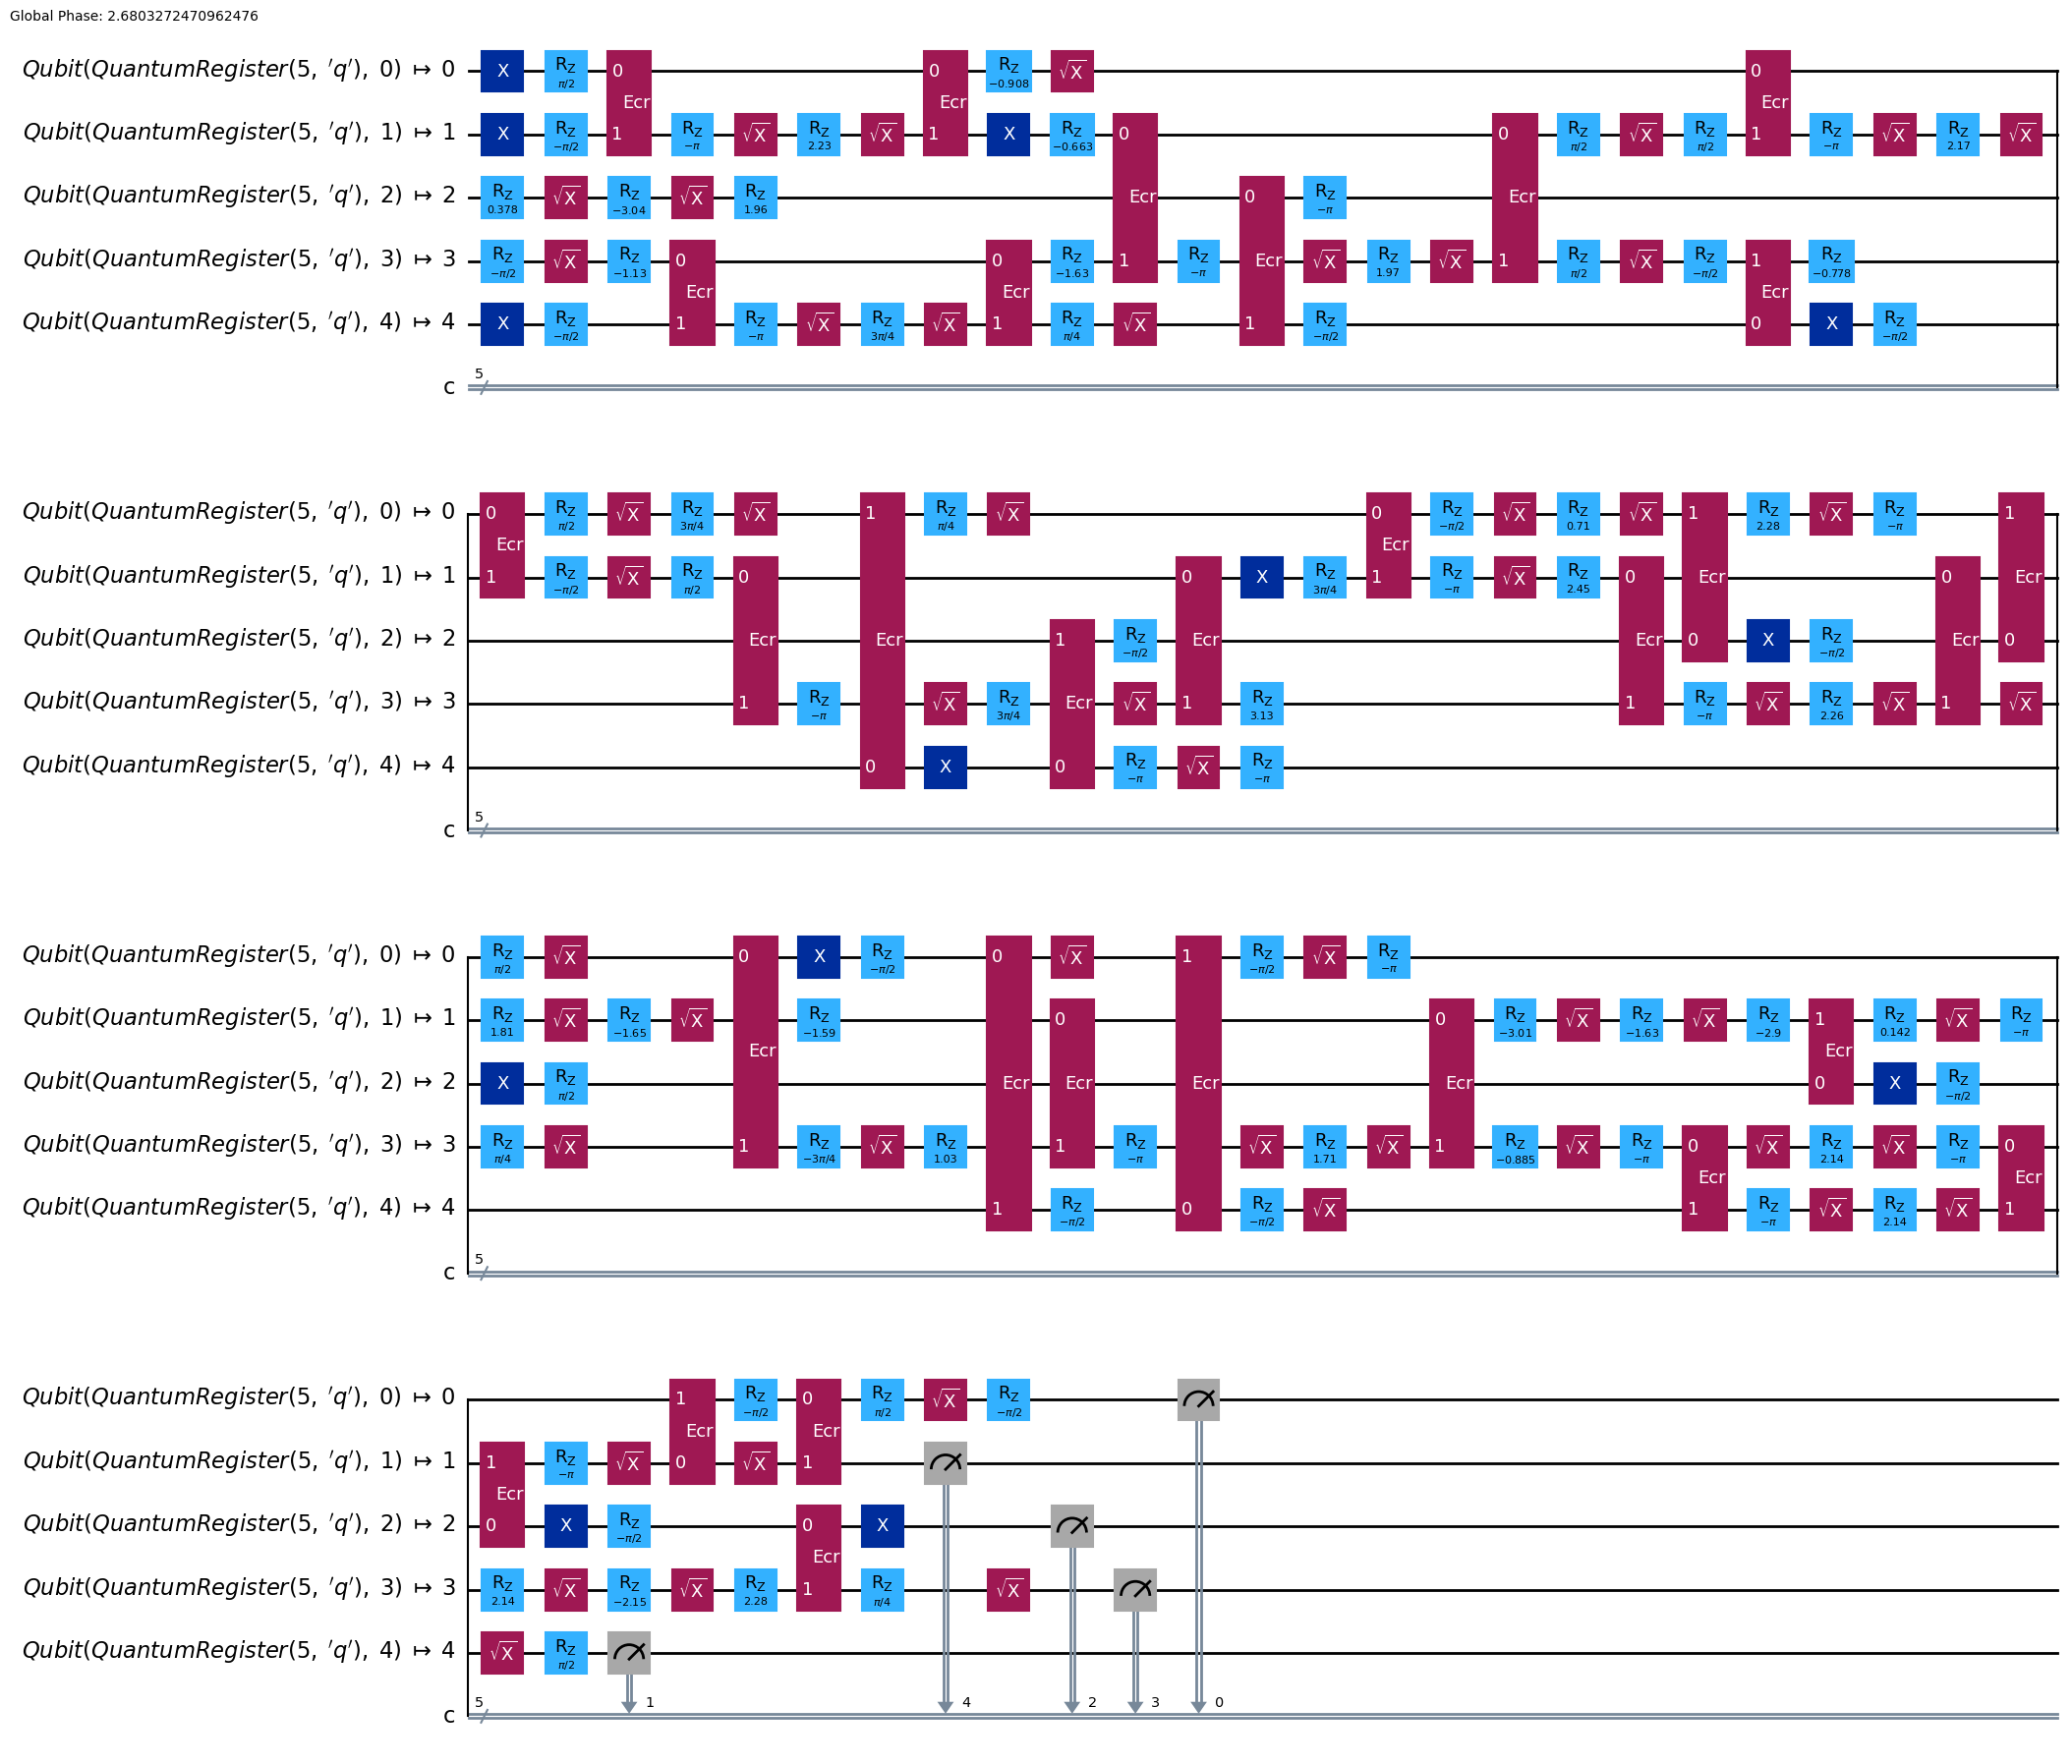

In [36]:
from qiskit import QuantumCircuit
from qiskit.circuit.random import random_circuit
from qiskit.converters import circuit_to_dag
from qiskit.visualization import dag_drawer
import matplotlib.pyplot as plt

transpiled_circ.draw('mpl')


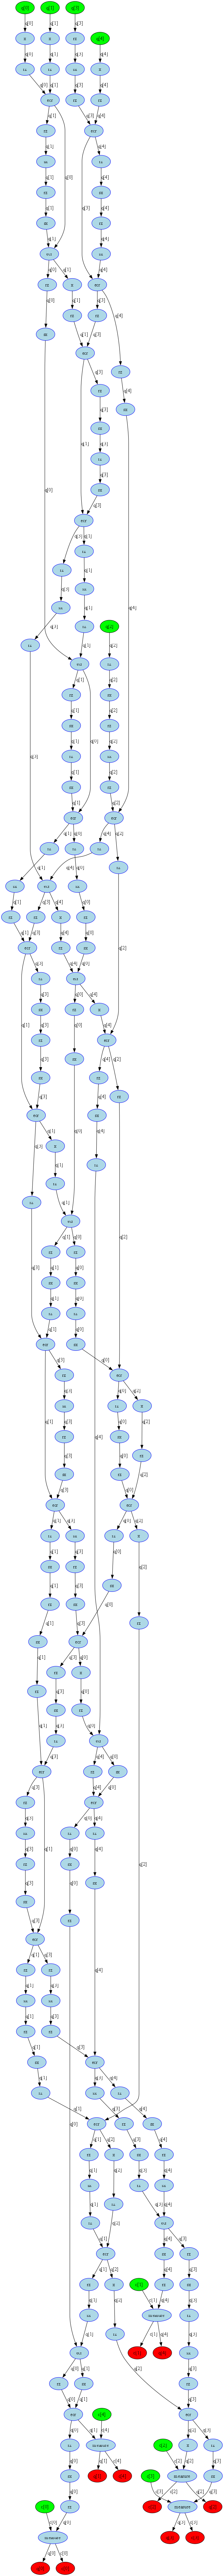

In [37]:

# Step 2: Convert to DAG
dag = circuit_to_dag(transpiled_circ)

# Step 3: Visualize the DAG
dag_drawer(dag, scale=0.8)  # Can use 'mpl' or 'text' backends


In [38]:
dag.qubits

[Qubit(QuantumRegister(5, 'q'), 0),
 Qubit(QuantumRegister(5, 'q'), 1),
 Qubit(QuantumRegister(5, 'q'), 2),
 Qubit(QuantumRegister(5, 'q'), 3),
 Qubit(QuantumRegister(5, 'q'), 4)]

In [39]:
dag.clbits

[Clbit(ClassicalRegister(5, 'c'), 0),
 Clbit(ClassicalRegister(5, 'c'), 1),
 Clbit(ClassicalRegister(5, 'c'), 2),
 Clbit(ClassicalRegister(5, 'c'), 3),
 Clbit(ClassicalRegister(5, 'c'), 4)]

In [40]:
dag.gate_nodes()

[DAGOpNode(op=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qargs=(Qubit(QuantumRegister(5, 'q'), 0),), cargs=()),
 DAGOpNode(op=Instruction(name='rz', num_qubits=1, num_clbits=0, params=[1.5707963267948966]), qargs=(Qubit(QuantumRegister(5, 'q'), 0),), cargs=()),
 DAGOpNode(op=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qargs=(Qubit(QuantumRegister(5, 'q'), 1),), cargs=()),
 DAGOpNode(op=Instruction(name='rz', num_qubits=1, num_clbits=0, params=[-1.5707963267948966]), qargs=(Qubit(QuantumRegister(5, 'q'), 1),), cargs=()),
 DAGOpNode(op=Instruction(name='ecr', num_qubits=2, num_clbits=0, params=[]), qargs=(Qubit(QuantumRegister(5, 'q'), 0), Qubit(QuantumRegister(5, 'q'), 1)), cargs=()),
 DAGOpNode(op=Instruction(name='rz', num_qubits=1, num_clbits=0, params=[-3.141592653589793]), qargs=(Qubit(QuantumRegister(5, 'q'), 1),), cargs=()),
 DAGOpNode(op=Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]), qargs=(Qubit(QuantumRegister(5, 'q'), 1),),

In [41]:
# Iterate through all edges in the DAG
for source_node, dest_node, wire in dag.edges():
    # Check the type of each node and access appropriate attributes
    if hasattr(source_node, 'op'):
        source_info = source_node.op.name
    else:
        source_info = type(source_node).__name__
        
    if hasattr(dest_node, 'op'):
        dest_info = dest_node.op.name
    else:
        dest_info = type(dest_node).__name__
        
    print(f"Edge connects {source_info} to {dest_info} via wire {wire}")


Edge connects DAGInNode to x via wire Qubit(QuantumRegister(5, 'q'), 0)
Edge connects DAGInNode to x via wire Qubit(QuantumRegister(5, 'q'), 1)
Edge connects DAGInNode to rz via wire Qubit(QuantumRegister(5, 'q'), 2)
Edge connects DAGInNode to rz via wire Qubit(QuantumRegister(5, 'q'), 3)
Edge connects DAGInNode to x via wire Qubit(QuantumRegister(5, 'q'), 4)
Edge connects DAGInNode to measure via wire Clbit(ClassicalRegister(5, 'c'), 0)
Edge connects DAGInNode to measure via wire Clbit(ClassicalRegister(5, 'c'), 1)
Edge connects DAGInNode to measure via wire Clbit(ClassicalRegister(5, 'c'), 2)
Edge connects DAGInNode to measure via wire Clbit(ClassicalRegister(5, 'c'), 3)
Edge connects DAGInNode to measure via wire Clbit(ClassicalRegister(5, 'c'), 4)
Edge connects x to rz via wire Qubit(QuantumRegister(5, 'q'), 0)
Edge connects rz to ecr via wire Qubit(QuantumRegister(5, 'q'), 0)
Edge connects x to rz via wire Qubit(QuantumRegister(5, 'q'), 1)
Edge connects rz to ecr via wire Qubit(Qu

In [42]:
# circ = random_circuit(num_qubits=2, depth=2, max_operands=2, measure=True, seed=42)
# circ.draw()

In [43]:
# dag = circuit_to_dag(circ)

In [44]:
# Initialize dictionaries for nodes, edges, and edge features
nodes = {'gates': {}, 'input': {}, 'output': {}}
edges = {}
edge_features = {}

# Function to extract qubit/clbit index from string or object
def extract_bit_index(bit_obj):
    if hasattr(bit_obj, 'index'):
        # If it's an actual qubit/clbit object
        return bit_obj.index
    else:
        # If it's a string representation, extract index using regex
        import re
        match = re.search(r'\), (\d+)\)', str(bit_obj))
        if match:
            return int(match.group(1))
        return str(bit_obj)  # Fallback

# Maintain a mapping to ensure each node is uniquely identified and stored only once
node_to_uid = {}

# Topological traversal for unique node identification
for node_idx, node in enumerate(dag.topological_nodes()):
    node_uid = f"node_{node_idx}"
    node_to_uid[node] = node_uid  # Store mapping

    if hasattr(node, 'op'):
        nodes['gates'][node_uid] = {
            'type': node.op.name,
            'qargs': [extract_bit_index(qarg) for qarg in node.qargs],
            'cargs': [extract_bit_index(carg) for carg in node.cargs]
        }
    else:
        node_type = type(node).__name__
        category = 'input' if 'In' in node_type else 'output'
        nodes[category][node_uid] = {
            'type': node_type,
            'qargs': [extract_bit_index(qarg) for qarg in getattr(node, 'qargs', [])],
            'cargs': [extract_bit_index(carg) for carg in getattr(node, 'cargs', [])]
        }

# Now process edges using the unique IDs
for edge_idx, (src, dst, wire) in enumerate(dag.edges()):
    src_id = node_to_uid[src]
    dst_id = node_to_uid[dst]
    
    edge_key = f"edge_{edge_idx}"
    edges[edge_key] = (src_id, dst_id)
    
    # Simplified edge feature - just store qubit/clbit index
    edge_features[edge_key] = extract_bit_index(wire)

# Output the dictionaries
nodes, edges, edge_features


({'gates': {'node_1': {'type': 'x', 'qargs': [0], 'cargs': []},
   'node_2': {'type': 'rz', 'qargs': [0], 'cargs': []},
   'node_4': {'type': 'x', 'qargs': [1], 'cargs': []},
   'node_5': {'type': 'rz', 'qargs': [1], 'cargs': []},
   'node_6': {'type': 'ecr', 'qargs': [0, 1], 'cargs': []},
   'node_7': {'type': 'rz', 'qargs': [1], 'cargs': []},
   'node_8': {'type': 'sx', 'qargs': [1], 'cargs': []},
   'node_9': {'type': 'rz', 'qargs': [1], 'cargs': []},
   'node_10': {'type': 'sx', 'qargs': [1], 'cargs': []},
   'node_11': {'type': 'ecr', 'qargs': [0, 1], 'cargs': []},
   'node_12': {'type': 'rz', 'qargs': [0], 'cargs': []},
   'node_13': {'type': 'sx', 'qargs': [0], 'cargs': []},
   'node_14': {'type': 'x', 'qargs': [1], 'cargs': []},
   'node_15': {'type': 'rz', 'qargs': [1], 'cargs': []},
   'node_17': {'type': 'rz', 'qargs': [2], 'cargs': []},
   'node_18': {'type': 'sx', 'qargs': [2], 'cargs': []},
   'node_19': {'type': 'rz', 'qargs': [2], 'cargs': []},
   'node_20': {'type': 's

In [45]:
import pandas as pd

df = pd.read_csv("ibm_brisbane_calibrations_2025-04-05T06_27_38Z.csv")
df.head()

,Qubit,T1 (us),T2 (us),Frequency (GHz),Anharmonicity (GHz),Readout assignment error,Prob meas0 prep1,Prob meas1 prep0,Readout length (ns),ID error,Z-axis rotation (rz) error,√x (sx) error,Pauli-X error,ECR error,Gate time (ns),Operational
0,0,237.363640,61.698830,4.721901,-0.311979,0.356201,0.529297,0.183105,1300,0.000128,0,0.000128,0.000128,NaN,NaN,True
1,1,336.399138,336.242161,4.815137,-0.309744,0.275879,0.092285,0.459473,1300,0.000421,0,0.000421,0.000421,1_0:0.00967508026334113,1_0:660,True
2,2,145.328940,105.727534,4.609652,-0.309088,0.247314,0.171875,0.322754,1300,0.001037,0,0.001037,0.001037,2_1:0.01757405071856616,2_1:660,True
3,3,328.581304,401.633505,4.875541,-0.309687,0.224121,0.107422,0.340820,1300,0.000189,0,0.000189,0.000189,3_2:0.015351619225949464,3_2:660,True
4,4,226.284908,171.492061,4.818193,-0.310371,0.285156,0.216797,0.353516,1300,0.000145,0,0.000145,0.000145,4_15:0.00547136290517769;4_3:0.003025739071771...,4_15:660;4_3:660;4_5:660,True


In [46]:
df.columns

Index(['Qubit', 'T1 (us)', 'T2 (us)', 'Frequency (GHz)', 'Anharmonicity (GHz)',
       'Readout assignment error ', 'Prob meas0 prep1 ', 'Prob meas1 prep0 ',
       'Readout length (ns)', 'ID error ', 'Z-axis rotation (rz) error ',
       '√x (sx) error ', 'Pauli-X error ', 'ECR error ', 'Gate time (ns)',
       'Operational'],
      dtype='object')

In [47]:
import pandas as pd
import re

# Assume df is already loaded
# For example: df = pd.read_csv('your_file.csv')

# ------------------------------
# 1. Create qubit_info dictionary
# ------------------------------
cols_qubit = [
    'T1 (us)', 'T2 (us)', 'Frequency (GHz)', 'Anharmonicity (GHz)',
    'Readout assignment error ', 'Prob meas0 prep1 ', 'Prob meas1 prep0 ',
    'Readout length (ns)'
]

qubit_info = {}
for idx, row in df.iterrows():
    qubit = row["Qubit"]
    qubit_info[qubit] = {col: row[col] for col in cols_qubit}

# ------------------------------
# 2. Create gate_errors dictionary
# ------------------------------
gate_errors = {}

# Simple gate errors (store one value per qubit)
gate_errors["id"] = {}
gate_errors["rz"] = {}
gate_errors["sx"] = {}
gate_errors["x"] = {}  # Pauli-X

for idx, row in df.iterrows():
    qubit = row["Qubit"]
    gate_errors["id"][qubit] = row["ID error "]
    gate_errors["rz"][qubit] = row["Z-axis rotation (rz) error "]
    gate_errors["sx"][qubit] = row["√x (sx) error "]
    gate_errors["x"][qubit] = row["Pauli-X error "]

# For ECR, store unordered pairs: key will be a tuple (min, max)
gate_errors["ecr"] = {}

# Regex pattern to capture connections and values: e.g. "0_1:0.009675" 
pattern = r'(\d+_\d+):([\d\.]+)'

for idx, row in df.iterrows():
    # Convert the ECR columns to strings
    ecr_err_str = str(row["ECR error "])
    ecr_time_str = str(row["Gate time (ns)"])
    
    # Find all (connection, value) pairs for errors and times
    error_pairs = re.findall(pattern, ecr_err_str)
    time_pairs = re.findall(pattern, ecr_time_str)
    
    # Process error pairs
    for conn, err_val in error_pairs:
        qubits = list(map(int, conn.split('_')))
        key = tuple(sorted(qubits))  # Ensure the pair is unordered
        if key not in gate_errors["ecr"]:
            gate_errors["ecr"][key] = {}
        gate_errors["ecr"][key]["error"] = float(err_val)
    
    # Process time pairs
    for conn, time_val in time_pairs:
        qubits = list(map(int, conn.split('_')))
        key = tuple(sorted(qubits))
        if key not in gate_errors["ecr"]:
            gate_errors["ecr"][key] = {}
        gate_errors["ecr"][key]["Gate time"] = float(time_val)

# ------------------------------
# Example: Print the dictionaries
# ------------------------------
print("Qubit Info:")
print(qubit_info)
print("\nGate Errors:")
print(gate_errors)


Qubit Info:
{0: {'T1 (us)': 237.363640207058, 'T2 (us)': 61.69883030137593, 'Frequency (GHz)': 4.721900993314522, 'Anharmonicity (GHz)': -0.3119786597343557, 'Readout assignment error ': 0.356201171875, 'Prob meas0 prep1 ': 0.529296875, 'Prob meas1 prep0 ': 0.18310546875, 'Readout length (ns)': 1300}, 1: {'T1 (us)': 336.39913815951826, 'T2 (us)': 336.24216097491245, 'Frequency (GHz)': 4.815136585640555, 'Anharmonicity (GHz)': -0.3097440319777085, 'Readout assignment error ': 0.27587890625, 'Prob meas0 prep1 ': 0.09228515625, 'Prob meas1 prep0 ': 0.45947265625, 'Readout length (ns)': 1300}, 2: {'T1 (us)': 145.32893982504785, 'T2 (us)': 105.7275339954369, 'Frequency (GHz)': 4.609652244377777, 'Anharmonicity (GHz)': -0.3090875180776862, 'Readout assignment error ': 0.247314453125, 'Prob meas0 prep1 ': 0.171875, 'Prob meas1 prep0 ': 0.32275390625, 'Readout length (ns)': 1300}, 3: {'T1 (us)': 328.58130446156446, 'T2 (us)': 401.6335047471614, 'Frequency (GHz)': 4.875541331889611, 'Anharmonic

In [48]:
gate_errors['sx']

{0: 0.0001282362534543,
 1: 0.0004210364105014,
 2: 0.0010365801696041,
 3: 0.0001892734109235,
 4: 0.0001447490970577,
 5: 0.0001854051533576,
 6: 0.0001822681517844,
 7: 0.0003255801825383,
 8: 0.0001195985544901,
 9: 0.0001506228564241,
 10: 0.0003712045285325,
 11: 0.000227471704608,
 12: 0.0002371096645965,
 13: 0.0002789352200019,
 14: 0.0004369959370666,
 15: 0.0003040711379266,
 16: 0.0002424911429782,
 17: 0.0001087663038719,
 18: 0.0002378615914599,
 19: 0.0005826676147514,
 20: 0.0001046725208097,
 21: 0.0001368764393772,
 22: 0.0001997334908058,
 23: 0.0001801496994212,
 24: 0.0001814424530228,
 25: 0.000281885468369,
 26: 0.0003700763180577,
 27: 0.000253352323017,
 28: 0.0002527323710651,
 29: 0.000180111248654,
 30: 0.0002534729112033,
 31: 0.000447825788861,
 32: 0.0001839240442298,
 33: 0.0003244502482995,
 34: 0.0001209861267061,
 35: 0.0001693865413254,
 36: 0.0001058104215588,
 37: 0.0001548603042363,
 38: 0.0003827956587173,
 39: 0.0002131612973038,
 40: 0.00039885

In [49]:
gate_errors['ecr']

{(0, 1): {'error': 0.00967508026334113, 'Gate time': 660.0},
 (1, 2): {'error': 0.01757405071856616, 'Gate time': 660.0},
 (2, 3): {'error': 0.015351619225949464, 'Gate time': 660.0},
 (4, 15): {'error': 0.00547136290517769, 'Gate time': 660.0},
 (3, 4): {'error': 0.0030257390717715604, 'Gate time': 660.0},
 (4, 5): {'error': 0.004708516861834766, 'Gate time': 660.0},
 (5, 6): {'error': 0.007407055654162886, 'Gate time': 660.0},
 (6, 7): {'error': 0.005224140390708121, 'Gate time': 660.0},
 (7, 8): {'error': 0.0041493751374495624, 'Gate time': 660.0},
 (8, 9): {'error': 0.0067086491201749365, 'Gate time': 660.0},
 (9, 10): {'error': 0.009793512002736149, 'Gate time': 660.0},
 (10, 11): {'error': 0.010294779885614336, 'Gate time': 660.0},
 (11, 12): {'error': 0.009639689223228887, 'Gate time': 660.0},
 (12, 17): {'error': 0.011176153298097458, 'Gate time': 660.0},
 (12, 13): {'error': 0.010888602232240085, 'Gate time': 660.0},
 (0, 14): {'error': 0.005347975510777092, 'Gate time': 660.0

process the node dict so that when qargs > 0 it applies apt gate_dict

In [50]:
nodes, edges, edge_features, qubit_info, gate_errors

({'gates': {'node_1': {'type': 'x', 'qargs': [0], 'cargs': []},
   'node_2': {'type': 'rz', 'qargs': [0], 'cargs': []},
   'node_4': {'type': 'x', 'qargs': [1], 'cargs': []},
   'node_5': {'type': 'rz', 'qargs': [1], 'cargs': []},
   'node_6': {'type': 'ecr', 'qargs': [0, 1], 'cargs': []},
   'node_7': {'type': 'rz', 'qargs': [1], 'cargs': []},
   'node_8': {'type': 'sx', 'qargs': [1], 'cargs': []},
   'node_9': {'type': 'rz', 'qargs': [1], 'cargs': []},
   'node_10': {'type': 'sx', 'qargs': [1], 'cargs': []},
   'node_11': {'type': 'ecr', 'qargs': [0, 1], 'cargs': []},
   'node_12': {'type': 'rz', 'qargs': [0], 'cargs': []},
   'node_13': {'type': 'sx', 'qargs': [0], 'cargs': []},
   'node_14': {'type': 'x', 'qargs': [1], 'cargs': []},
   'node_15': {'type': 'rz', 'qargs': [1], 'cargs': []},
   'node_17': {'type': 'rz', 'qargs': [2], 'cargs': []},
   'node_18': {'type': 'sx', 'qargs': [2], 'cargs': []},
   'node_19': {'type': 'rz', 'qargs': [2], 'cargs': []},
   'node_20': {'type': 's